In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
np.random.seed(42)

n = 200

data = {
    "study_hours": np.random.randint(1, 10, n),
    "attendance": np.random.randint(50, 100, n),
    "assignments_completed": np.random.randint(0, 10, n),
    "previous_grade": np.random.randint(40, 100, n),
    "gender": np.random.choice(["Male", "Female"], n),
    "internet_access": np.random.choice(["Yes", "No"], n),
}

df = pd.DataFrame(data)

# Create target variable (pass/fail based on logic)
df["pass_fail"] = (
    (df["study_hours"] > 4) &
    (df["attendance"] > 60) &
    (df["previous_grade"] > 50)
).astype(int)

df.to_csv("student_data.csv", index=False)

df.head()

,study_hours,attendance,assignments_completed,previous_grade,gender,internet_access,pass_fail
0,7,50,8,50,Female,No,0
1,4,60,4,99,Male,No,0
2,8,77,0,76,Female,Yes,1
3,5,74,9,75,Female,No,1
4,7,99,9,74,Male,No,1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   study_hours            200 non-null    int64 
 1   attendance             200 non-null    int64 
 2   assignments_completed  200 non-null    int64 
 3   previous_grade         200 non-null    int64 
 4   gender                 200 non-null    object
 5   internet_access        200 non-null    object
 6   pass_fail              200 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 11.1+ KB


,study_hours,attendance,assignments_completed,previous_grade,pass_fail
count,200.00000,200.000000,200.00000,200.000000,200.000000
mean,5.07000,76.410000,4.60500,69.705000,0.365000
std,2.63435,13.964488,3.00234,17.829961,0.482638
min,1.00000,50.000000,0.00000,40.000000,0.000000
25%,3.00000,66.000000,2.00000,54.000000,0.000000
50%,5.00000,77.000000,4.00000,69.000000,0.000000
75%,7.00000,87.000000,7.00000,87.000000,1.000000
max,9.00000,99.000000,9.00000,99.000000,1.000000


In [6]:
df.isnull().sum()

df.ffill(inplace=True)

## Data Cleaning Approach
Missing values were handled using forward fill and statistical techniques.
Categorical variables were encoded using Label Encoding.

In [7]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [8]:
X = df.drop("pass_fail", axis=1)
y = df["pass_fail"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Why Decision Tree and Logistic Regression?

Decision Tree is chosen for its interpretability and ability to capture non-linear relationships.  
Logistic Regression is used as a baseline linear model for comparison.

In [12]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Decision Tree Accuracy: 0.975
Logistic Regression Accuracy: 0.8


In [13]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.90      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



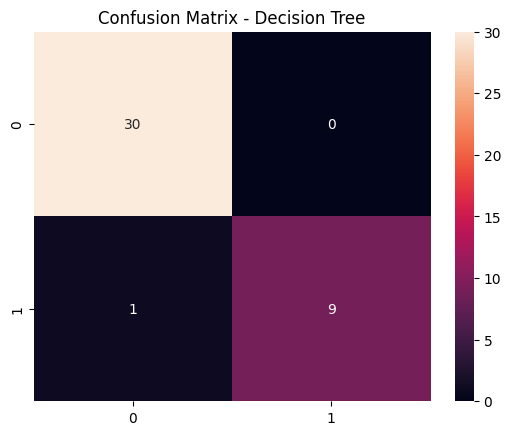

In [14]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Model Evaluation
Models are evaluated using accuracy, confusion matrix, and classification report.

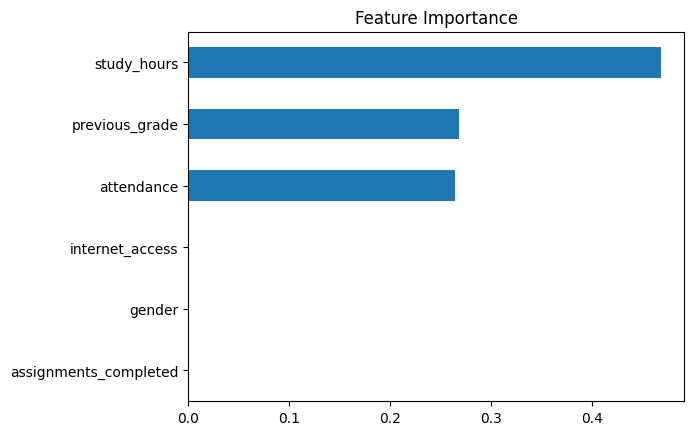

In [15]:
importance = dt.feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

## Feature Importance
Feature importance helps identify the most influential factors affecting student performance.

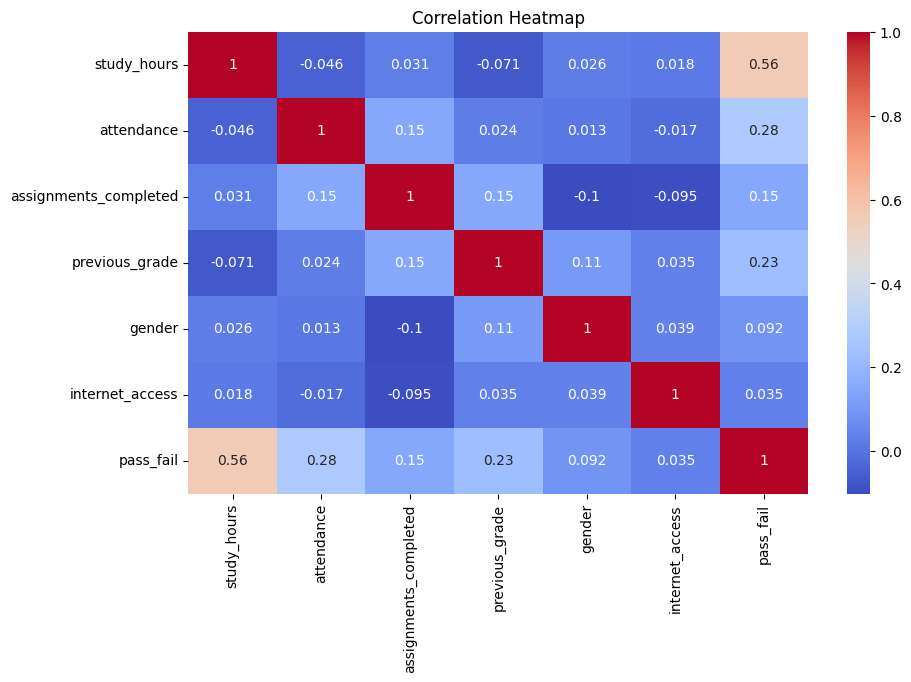

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

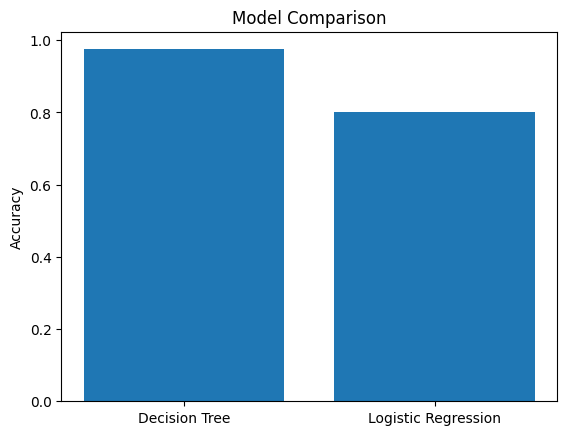

In [17]:
models = ['Decision Tree', 'Logistic Regression']
scores = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_lr)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## Model Comparison
Decision Tree performed better due to its ability to capture complex relationships,
while Logistic Regression provided a good baseline.

## Conclusion

The model successfully predicts student performance with good accuracy.  
Attendance and study hours are the most significant predictors.

This model can help educational institutions identify at-risk students early and take preventive measures.